In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from src.data import load_diabetes_data

In [2]:
X, y, target_name = load_diabetes_data(binary=True)

print(f"Rows: {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Target: {target_name}")

Rows: 253680
Features: 21
Target: diabetes_binary


In [3]:
missing_values = X.isna().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [4]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
highbp,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
highchol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
cholcheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
bmi,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
heartdiseaseorattack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
physactivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0
veggies,253680.0,0.811420,0.391175,0.0,1.0,1.0,1.0,1.0


In [5]:
df = X.copy()
df[target_name] = y

df.head()

,highbp,highchol,cholcheck,bmi,smoker,stroke,heartdiseaseorattack,physactivity,fruits,veggies,...,nodocbccost,genhlth,menthlth,physhlth,diffwalk,sex,age,education,income,diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [6]:
group_means = df.groupby(target_name).mean().T
group_means["difference"] = group_means[1] - group_means[0]
group_means.sort_values("difference", ascending=False)

diabetes_binary,0,1,difference
physhlth,3.641082,7.954479,4.313397
bmi,27.805770,31.944011,4.138241
age,7.814065,9.379053,1.564988
menthlth,2.978034,4.461806,1.483772
genhlth,2.385185,3.290981,0.905796
highbp,0.376602,0.752674,0.376072
highchol,0.384297,0.670118,0.285822
diffwalk,0.135361,0.371216,0.235855
heartdiseaseorattack,0.073351,0.222882,0.149531
smoker,0.431019,0.518220,0.087201


In [7]:
correlations = df.corr(numeric_only=True)[target_name].drop(target_name)
correlations = correlations.sort_values(key=lambda s: s.abs(), ascending=False)

correlations.head(10)

genhlth                 0.293569
highbp                  0.263129
diffwalk                0.218344
bmi                     0.216843
highchol                0.200276
age                     0.177442
heartdiseaseorattack    0.177282
physhlth                0.171337
income                 -0.163919
education              -0.124456
Name: diabetes_binary, dtype: float64

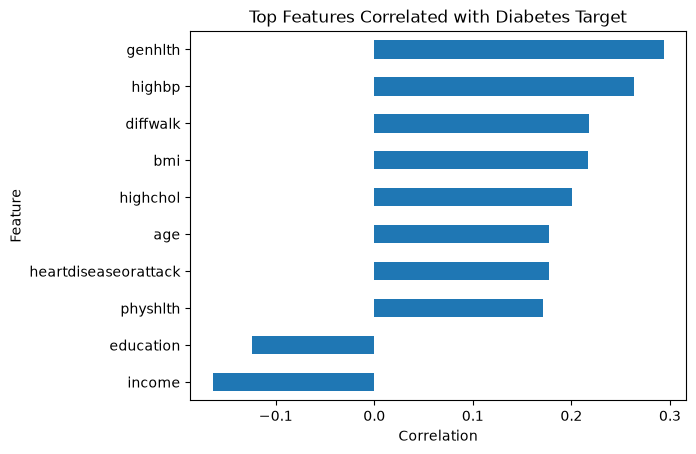

In [8]:
top_corr = correlations.head(10).sort_values()

top_corr.plot(kind="barh")

plt.title("Top Features Correlated with Diabetes Target")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()